In [1]:
import sys, os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import glob
import pandas as pd
import ast
import itertools
import numpy as np
from pathlib import Path

In [2]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [3]:
import warnings
warnings.filterwarnings("ignore")

### Analyzing Language

We use all text in each posts and perform the following steps:

1. Remove irrelevant characters/words:
    - Filter emojis  
    - Special characters & Punctutations $\text{(!><?\_= ...)}$
    - Language stopwords (pronouns, adverbs, articles, ...)
    
    
2. Text Normalization:  
    - Lemmanization -> keep context to morphological analysis  
    - Stemming -> keep the stem of the word to content analysis   
    - None -> keep all words
    
    
3. Language Evaluation:

We define an indicator language function (ilf) or $\large{ \boldsymbol{\mathbb{1}}_{ilf} }$ as:

$$\large{ \boldsymbol{\mathbb{1}}_{ilf}(word, language) } = \left \{ \begin{array}{rcl}
    1, & \text{if word belongs to language} \\
    0, & \text{otherwise}
    \end{array}
    \right.$$
    
Then, a language ratio as:

$$\large{Ratio_{lrf} (text, language_j) } = \frac{1}{\text{Total words in text}} \sum_{\substack{i=1 \\ \text{word}_i \in \text{ text} } }^{n} \boldsymbol{\mathbb{1}}_{ilf}(word_i, language_j) $$

Finally, we choose the language with highest score:

$$\large language(text) = \max_{\forall lang \in \text{languages list}} Ratio_{lrf} (text, lang)$$

### Loading package

In [4]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [5]:
from py.utils import verifyDir,verifyFile

In [6]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [7]:
DATA_PATH=f"{cfg.DATA_PATH}crimebb/"
CSV_PATH = f"{DATA_PATH}/{cfg.YEAR}/csv/"
HF_PROCESSED = f"{DATA_PATH}/{cfg.YEAR}/csv/topics/{cfg.TOPIC_SEARCH}/"

In [8]:
df = pd.read_csv(f"{HF_PROCESSED}HackForums_CVE_Threads_and_Labels.csv", sep="\t", low_memory=False)
df["cve_codes_list"] = df["cve_codes_list"].apply(ast.literal_eval)
df["cve_unique_list"] = df["cve_unique_list"].apply(ast.literal_eval)
df

,thread_id,annotations,site_id,site_name,board_id,board_title,thread_title,content,cve_codes_list,cve_unique_list,r_IMG,r_CITING,r_IFRAME,r_LINK,r_CODE,r_ATTACHMENT,r_QUOTE,content_orig
0,3205,poc,0,hackforums.net,4,Beginner Hacking,"Almost there, just need a little help. :)","I found these, but how do I exploit them? \n\n...","[cve, cve-2005-4659, cve, cve-2005-4659]","[cve, cve-2005-4659]",[],[],[],['http://secunia.com/advisories/17271/[https:/...,[],[],[],"I found these, but how do I exploit them? \n\n..."
1,9393,poc,0,hackforums.net,4,Beginner Hacking,SMF 1.1.2 Exploit,you should already have this site in your book...,"[cve, cve-2007-2546, cve, cve-2007-2546]","[cve, cve-2007-2546]",[],[],[],['http://nvd.nist.gov/nvd.cfm?cvename=CVE-2007...,[],[],[],you should already have this site in your book...
2,9768,poc,0,hackforums.net,4,Beginner Hacking,College see other computers?,There is a really good easy to use program tha...,"[cve-2002-0656, cve, cve, cve, cve, cve, cve, ...","[cve, cve-2002-0656]",[],[],[],['http://phenoelit-us.org/irpas/docu.html#ass[...,[],[],[],There is a really good easy to use program tha...
3,14121,poc,0,hackforums.net,25,The Lounge,What is your Ctrl+V?,FAMVEER \n:o,"[cve, cve-2007-4453, cve, cve-2007-4453]","[cve, cve-2007-4453]",[],[],[],['http://nvd.nist.gov/nvd.cfm?cvename=CVE-2007...,[],[],['ctrl+v Wrote:***LINK***http://nvd.nist.gov/n...,***QUOTE***ctrl+v Wrote:***LINK***http://nvd.n...
4,24083,poc,0,hackforums.net,240,"Networking, Routers, Switches, and Firewalls",Get through a Router,"Any chance it's a Linksys WRT54G? If so, you'...","[cve, cve-2008-1247, cve, cve-2008-1247]","[cve, cve-2008-1247]",[],[],[],['https://kinqpinz.info/lib/wrt54g/[https://ki...,[],[],[],"Any chance it's a Linksys WRT54G? If so, you'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,5911636,others,0,hackforums.net,110,"White Hat Malware, Virus, and Rat Removal Help",Properly securing Windows 10 from being broken...,FAMVEER \nLinux is still vulnerable. Just les...,"[cve-2018-14634, cve-2018-17182]","[cve-2018-14634, cve-2018-17182]",[],['[https://hackforums.net/showthread.php?pid=5...,[],[],[],[],[],***CITING***[https://hackforums.net/showthread...
1063,5911742,weaponization,0,hackforums.net,10,Hacking Tools and Programs,"0day research, Exploit Developer for hire",Hey. Im Thomas Vanhoutte\n\nIm security resear...,"[cve, cve-2017-0226]","[cve, cve-2017-0226]",[],[],[],[],[],[],[],Hey. Im Thomas Vanhoutte\n\nIm security resear...
1064,5914710,weaponization,0,hackforums.net,176,Secondary Sellers Market,Exodia Silent Exploit - FUD [BEST] Version 2.0.0,exodiasoftware@hotmail.com\nSkype: live:6dc13d...,[cve-2018-8414],[cve-2018-8414],[],[],['[https://www.youtube.com/embed/AhUHFscD9EI]'],['[https://imageshack.com/i/pnhhXskuj]'],[],[],[],exodiasoftware@hotmail.com\nSkype: live:6dc13d...
1065,5916021,help,0,hackforums.net,4,Beginner Hacking,ExploitLooking for Silent doc/pdf Exploit Builder,FAMVEER \n\nA quick and easy microsoft word e...,"[cve-2017-0199, cve-2017-0199, cve]","[cve, cve-2017-0199]",['[https://img.wonderhowto.com/img/33/38/63643...,['[https://hackforums.net/showthread.php?pid=5...,[],['https://github.com/bhdresh/CVE-2017-0199[htt...,['[Microsoft Office 2007 Service Pack 3\nMicro...,[],[],***CITING***[https://hackforums.net/showthread...


### Analyze language

In [9]:
from py.nlpToolkit import LanguageProcesser

In [10]:
LANGUAGE_TO_EVAL=["english", "deutsch", "portuguese", "russian", "spanish"]

In [11]:
language_processer = LanguageProcesser(languages_to_eval=LANGUAGE_TO_EVAL,
                                       log=False,
                                        #exclude_pipe=['tagger', 'parser', 'ner']
                                       exclude_pipe=['morphologizer', "parser", "tagger", 'attribute_ruler', "ner"]
                                      )

In [12]:
for index, row in tqdm(df.iterrows()):
    language_processer.detect_language_and_word_list(row["content"])

    df.loc[index, "unique_word_ratio"] = [language_processer.get_language_ratios()]
    df.loc[index, "all_word_ratio"] = [language_processer.get_all_language_ratios()]

    df.loc[index, "lang_detected"] = language_processer.get_detected_language()
    df.loc[index, "lang_ratio"] = language_processer.get_detected_language_ratio()

    df.loc[index, "correct_words_dict"] = list([{"words": language_processer.get_correct_words()}])
    df.loc[index, "incorrect_words_dict"] = list([{"words": language_processer.get_incorrect_words()}])
    #df.loc[index, "words"] = language_processer.get_processed_text()

0it [00:00, ?it/s]

In [13]:
df["lang_detected"].value_counts()

lang_detected
english       1050
not found       13
portuguese       3
russian          1
Name: count, dtype: int64

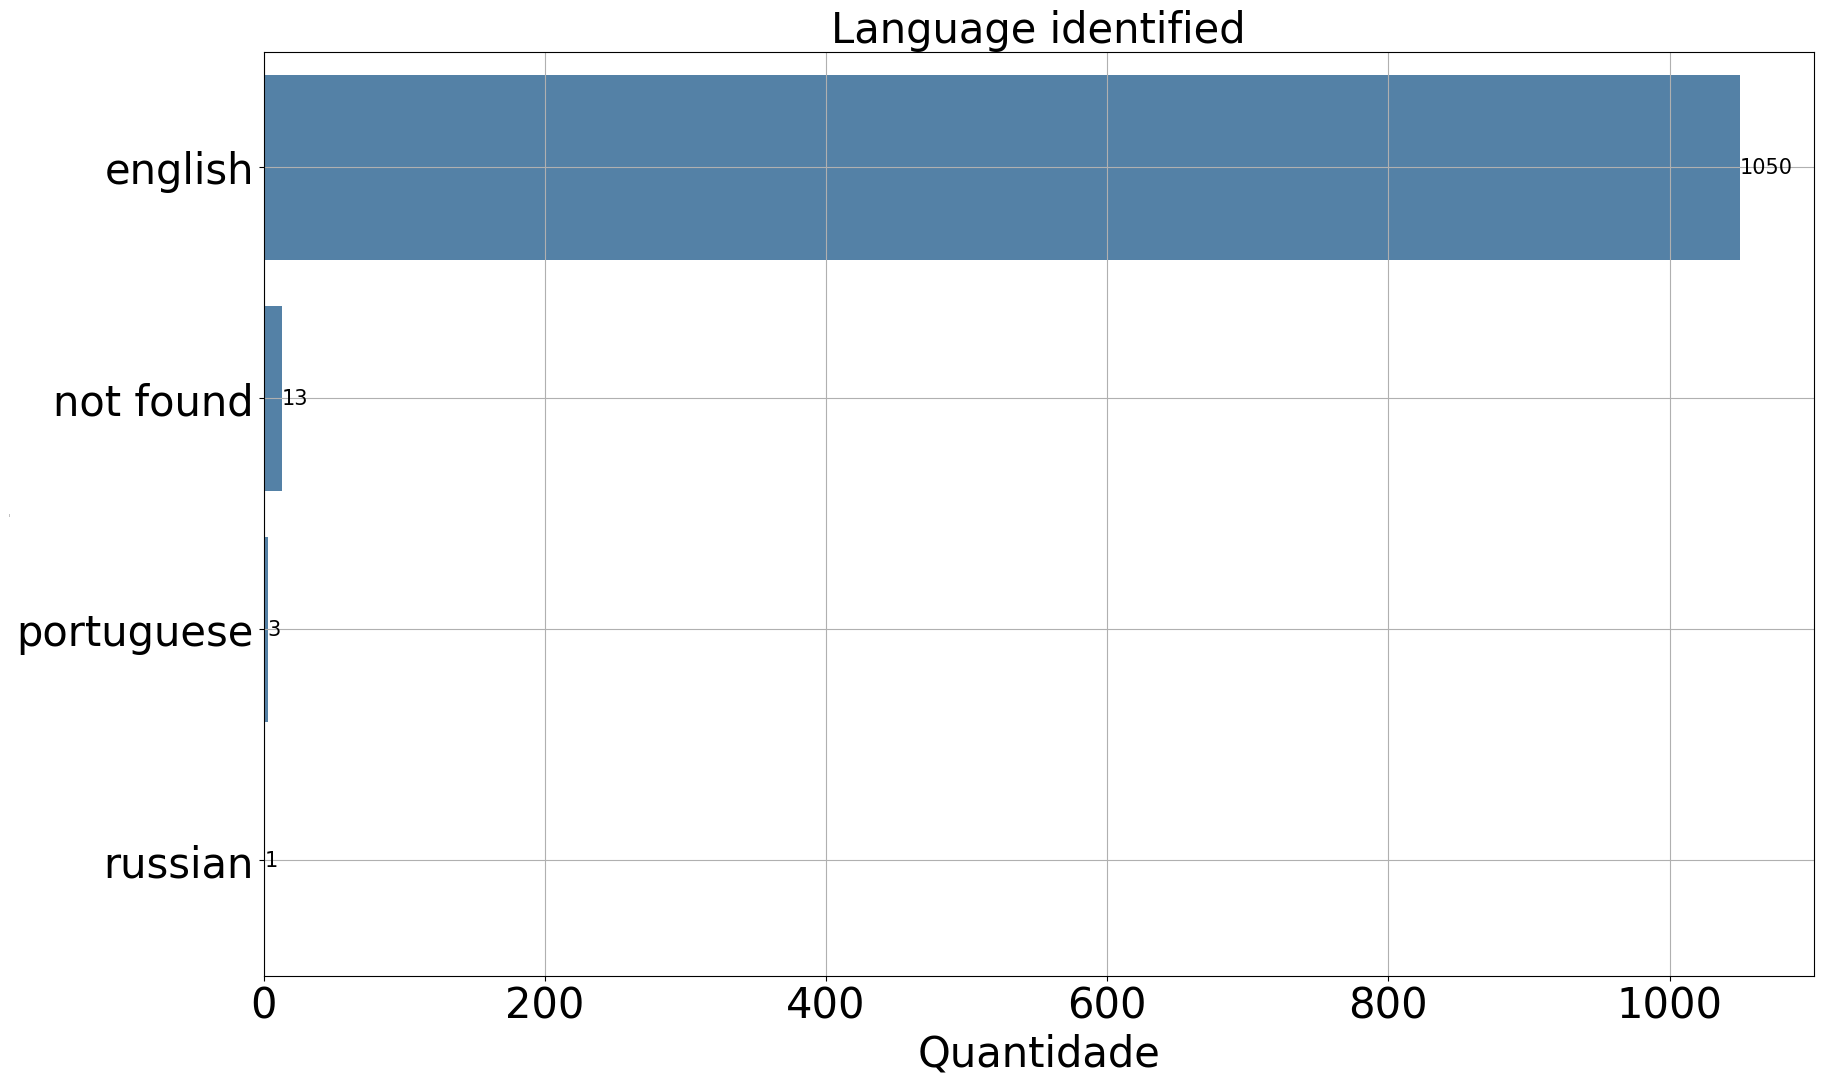

In [14]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(df,
               index=["lang_detected"],
                values=["thread_id"],
                aggfunc={
                    "thread_id":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Language identified", fontsize=30)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantidade', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=30)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

In [15]:
df["annotations"].value_counts()

annotations
weaponization    410
poc              247
others           195
exploitation     107
warning           55
help              43
scam              10
Name: count, dtype: int64

In [16]:
df[(df["lang_detected"]=="not found") ].sort_values(by="lang_ratio")

,thread_id,annotations,site_id,site_name,board_id,board_title,thread_title,content,cve_codes_list,cve_unique_list,...,r_CODE,r_ATTACHMENT,r_QUOTE,content_orig,unique_word_ratio,all_word_ratio,lang_detected,lang_ratio,correct_words_dict,incorrect_words_dict
3,14121,poc,0,hackforums.net,25,The Lounge,What is your Ctrl+V?,FAMVEER \n:o,"[cve, cve-2007-4453, cve, cve-2007-4453]","[cve, cve-2007-4453]",...,[],[],['ctrl+v Wrote:***LINK***http://nvd.nist.gov/n...,***QUOTE***ctrl+v Wrote:***LINK***http://nvd.n...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
16,67614,poc,0,hackforums.net,47,Hacking Tutorials,XSS with mod_perl perl_status utility,FAMVEER,"[cve, cve-2009-0796]","[cve, cve-2009-0796]",...,[],[],['Quote:Vulnerability found: 28th February 200...,***QUOTE***Quote:Vulnerability found: 28th Feb...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
18,78717,poc,0,hackforums.net,13,Computer Protection and Security Alerts,[News] Security Update for Adobe Reader & Acrobat,FAMVEER ... 09-06.html\n\n FAMVEER,"[cve-2009-1492, cve-2009-1493]","[cve-2009-1493, cve-2009-1492]",...,[],[],['Quote:A critical vulnerability has been iden...,***LINK***http://www.adobe.com/support/securit...,"[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...",not found,0.0,[{'words': []}],[{'words': ['html']}]
63,688221,others,0,hackforums.net,92,"Botnets, IRC Bots, and Zombies",*****Everyone on hack forum come and see my 1k...,FAMVEER \n FAMVEER \n\nYou dumbass,[cve-2010-3128],[cve-2010-3128],...,[],[],[],***CITING***[https://hackforums.net/showthread...,"[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...",not found,0.0,[{'words': []}],"[{'words': ['dumbass', 'you']}]"
66,720444,others,0,hackforums.net,103,SQL Injection Attacks,sqli playtime,FAMVEER \n FAMVEER \n FAMVEER \n FAMVEER \n F...,"[cve-2006-4893, cve-2008-0807]","[cve-2006-4893, cve-2008-0807]",...,[],[],[],***LINK***http://www.soaw.org/article.php?id='...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
110,1399636,poc,0,hackforums.net,89,News and Happenings,Another Zero Day Adobe Flash Player,FAMVEER \n\n\n FAMVEER,"[cve-2011-2110, cve-2011-2110, cve-2011-2110]",[cve-2011-2110],...,[],[],['Quote:Hackers are aggressively exploiting a ...,***LINK***View source here![http://www.compute...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
243,3005046,weaponization,0,hackforums.net,10,Hacking Tools and Programs,zero-day Java drive by totally for free.,CVE-2012-1723\n\n FAMVEER,"[cve-2012-1723, cve-2012-1723]",[cve-2012-1723],...,[],[],[],CVE-2012-1723\n\n***LINK***http://blog.eset.co...,"[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...","[{'english': 0.0, 'deutsch': 0.0, 'portuguese'...",not found,0.0,[{'words': []}],[{'words': ['cve']}]
260,3147157,poc,0,hackforums.net,4,Beginner Hacking,[INFO] New Exploit Pack ? [INFO],FAMVEER \n FAMVEER \n FAMVEER,"[cve-2013-0640, cve-2013-0640]",[cve-2013-0640],...,[],[],[],***CITING***[https://hackforums.net/showthread...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}],[{'words': []}]
274,3182586,others,0,hackforums.net,163,Marketplace Discussions,Oracle Patches Java Zero Day Vulnerability,FAMVEER \n FAMVEER,[cve-2013-0422],[cve-2013-0422],...,[],[],"[""Quote:Oracle delivered an unusual emergency ...",***QUOTE***Quote:Oracle delivered an unusual e...,"[{'english': 0, 'deutsch': 0, 'portuguese': 0,...","[{'english': 0, 'deutsch': 0, 'portuguese': 0,...",not found,0.0,[{'words': []}]

In [17]:
df[(df["lang_detected"]=="russian") ]["content"].values

<ArrowStringArray>
['[RUS]\nCVE-2017-11882+CVE-2018-0802\nТребуются регулярные чистки и стабильные реализации. Дорого.\n\nПрисылайте жаббер в ПМ \n\nКидалы/сомнительные личности/любители наебать - лесом, не тратьте свое и мое время.\n\n[ENG]\nI'm looking for a stable FUD or nearly FUD CVE-2017-11882+CVE-2018-0802 PoC realisations.\n\nsend your jabber in PM \n\nScumbags are not welcome, do not waste ur time.']
Length: 1, dtype: str

In [18]:
df.to_csv(f"{HF_PROCESSED}HackForums_Languages.csv", sep='\t', index=False)

### Languages

In [19]:
lang_post_df = df.pivot_table(columns=['lang_detected'], aggfunc='size')
lang_post_df.sort_values(ascending=False, inplace=True)
lang_post_df

lang_detected
english       1050
not found       13
portuguese       3
russian          1
dtype: int64

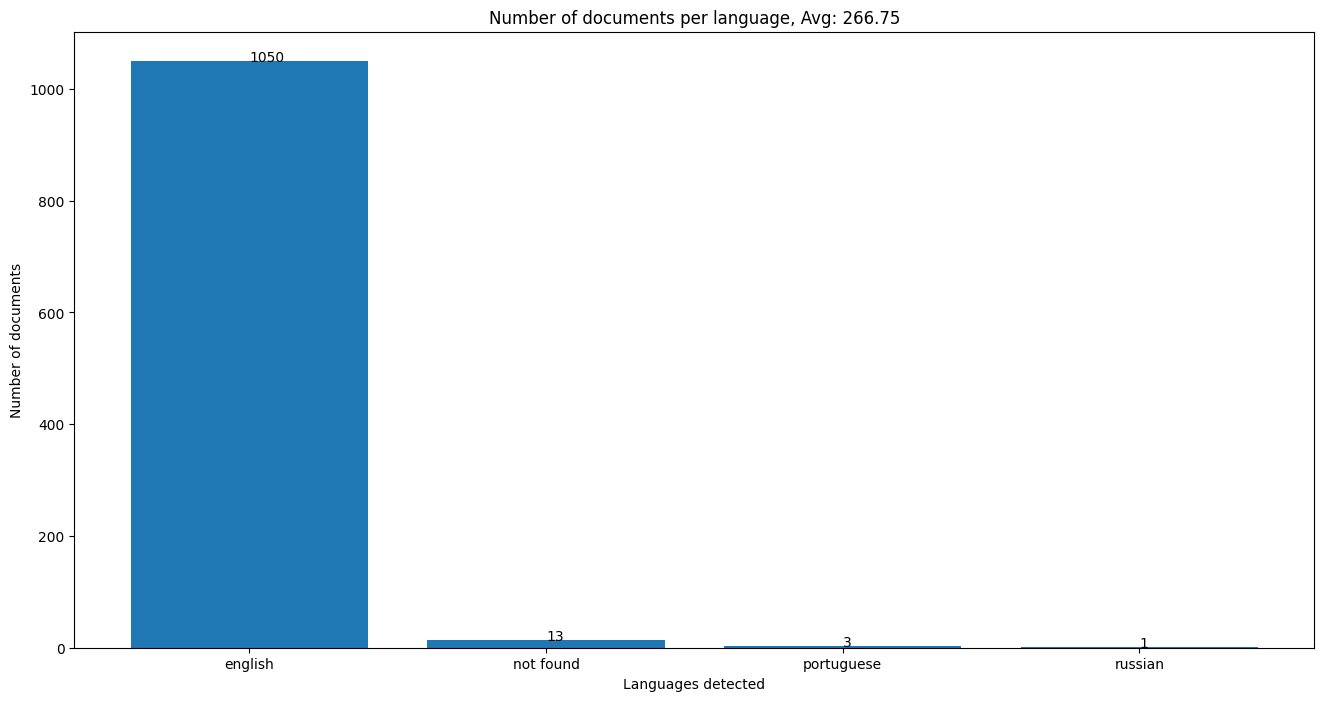

In [20]:
mean_val = round(lang_post_df.mean(), 2)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,8))
ax.bar(lang_post_df.index.values, lang_post_df.values)

for x,y,p in zip(lang_post_df.index.values, lang_post_df.values, lang_post_df.values):
  plt.text(x, y, p)
plt.xlabel("Languages detected")
plt.ylabel("Number of documents")
plt.title(f"Number of documents per language, Avg: {mean_val}")
plt.show()

### Wordclouds

In [29]:
from py.nlpToolkit import WordCloudPlotter

wc = WordCloudPlotter(language_to_process=LANGUAGE_TO_EVAL,
                      mask=None, 
                      exclude_pipe=['morphologizer', "parser", "tagger", 'attribute_ruler', "ner"],
                     )

#### Russian

In [23]:
russian_df = df[df["lang_detected"]=="russian"].copy()
russian_df.info(), russian_df.shape, russian_df.iloc[0,:]

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 978 to 978
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   thread_id             1 non-null      int64  
 1   annotations           1 non-null      str    
 2   site_id               1 non-null      int64  
 3   site_name             1 non-null      str    
 4   board_id              1 non-null      int64  
 5   board_title           1 non-null      str    
 6   thread_title          1 non-null      str    
 7   content               1 non-null      str    
 8   cve_codes_list        1 non-null      object 
 9   cve_unique_list       1 non-null      object 
 10  r_IMG                 1 non-null      str    
 11  r_CITING              1 non-null      str    
 12  r_IFRAME              1 non-null      str    
 13  r_LINK                1 non-null      str    
 14  r_CODE                1 non-null      str    
 15  r_ATTACHMENT          1 non-null  

(None,
 (1, 24),
 thread_id                                                         5792395
 annotations                                                          help
 site_id                                                                 0
 site_name                                                  hackforums.net
 board_id                                                               44
 board_title                                                    Buyers Bay
 thread_title                             CVE-2017-11882+CVE-2018-0802 FUD
 content                 [RUS]\nCVE-2017-11882+CVE-2018-0802\nТребуются...
 cve_codes_list          [cve-2017-11882, cve-2018-0802, cve-2017-11882...
 cve_unique_list                           [cve-2017-11882, cve-2018-0802]
 r_IMG                                                                  []
 r_CITING                                                               []
 r_IFRAME                                                               []
 r_LINK 

In [31]:
documents_content = ' '.join(russian_df["content"])

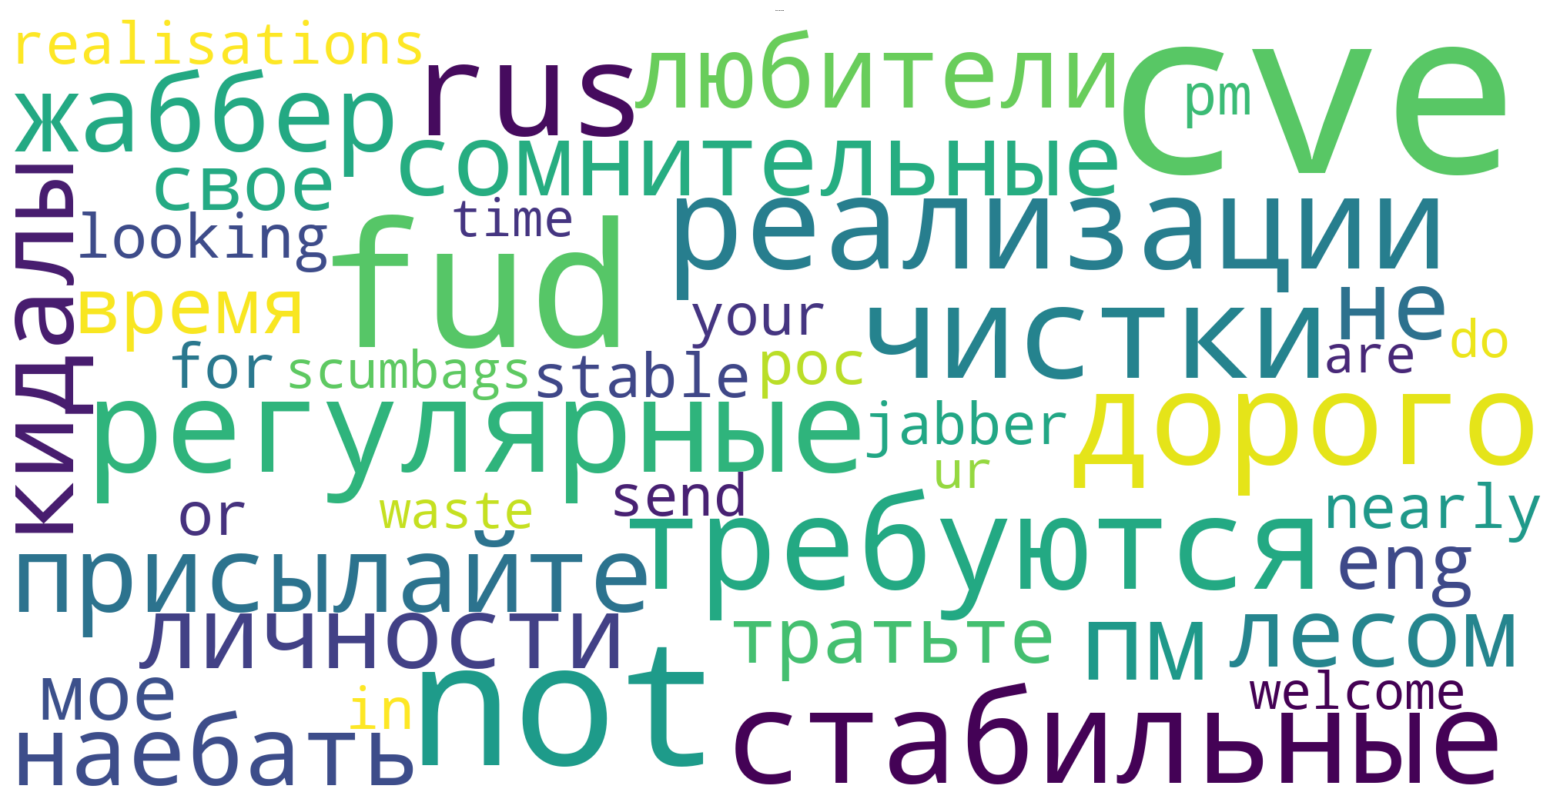

CPU times: user 1.81 s, sys: 779 ms, total: 2.59 s
Wall time: 2.71 s


In [32]:
%%time
wc.calculate_words_frequency(documents_content, languages_list=LANGUAGE_TO_EVAL)
wc.plotWordCloud(f"All-Wordcloud", fontsize=0)

#### Portuguese

In [43]:
pt_df = df[df["lang_detected"]=="portuguese"].copy()
pt_df.info(), pt_df.shape, pt_df.iloc[0,:]

<class 'pandas.DataFrame'>
Index: 3 entries, 209 to 852
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   thread_id             3 non-null      int64  
 1   annotations           3 non-null      str    
 2   site_id               3 non-null      int64  
 3   site_name             3 non-null      str    
 4   board_id              3 non-null      int64  
 5   board_title           3 non-null      str    
 6   thread_title          3 non-null      str    
 7   content               3 non-null      str    
 8   cve_codes_list        3 non-null      object 
 9   cve_unique_list       3 non-null      object 
 10  r_IMG                 3 non-null      str    
 11  r_CITING              3 non-null      str    
 12  r_IFRAME              3 non-null      str    
 13  r_LINK                3 non-null      str    
 14  r_CODE                3 non-null      str    
 15  r_ATTACHMENT          3 non-null      s

(None,
 (3, 24),
 thread_id                                                         2822128
 annotations                                                        others
 site_id                                                                 0
 site_name                                                  hackforums.net
 board_id                                                                4
 board_title                                              Beginner Hacking
 thread_title                                               port 3389 help
 content                 Perhaps you're refering to this:\nCVE-2012-000...
 cve_codes_list                                  [cve-2012-0002, cve, cve]
 cve_unique_list                                      [cve, cve-2012-0002]
 r_IMG                                                                  []
 r_CITING                                                               []
 r_IFRAME                                                               []
 r_LINK 

In [41]:
documents_content = ' '.join(pt_df["content"])

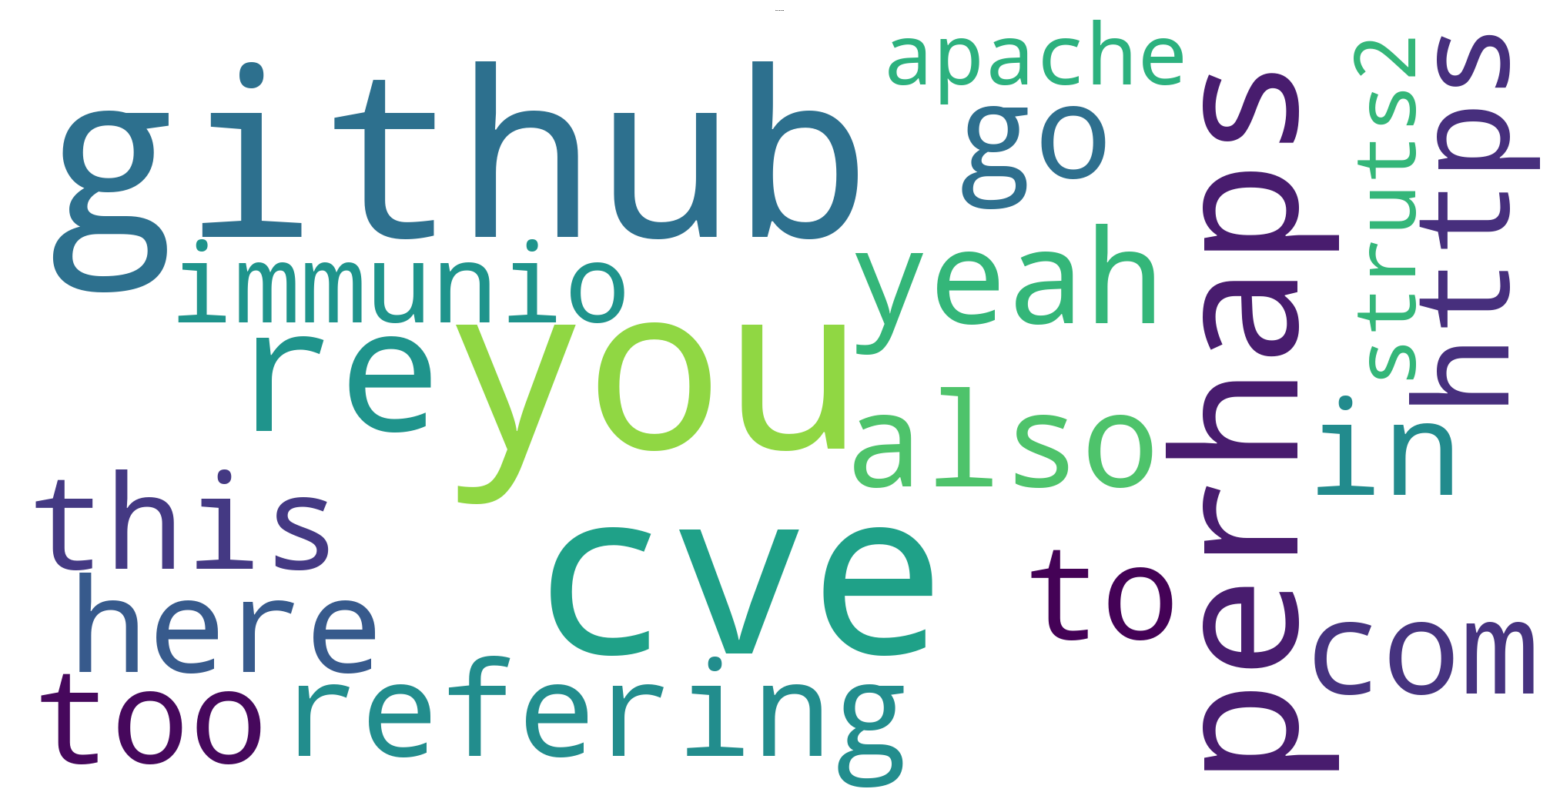

CPU times: user 1.62 s, sys: 754 ms, total: 2.37 s
Wall time: 2.5 s


In [42]:
%%time
wc.calculate_words_frequency(documents_content, languages_list=LANGUAGE_TO_EVAL)
wc.plotWordCloud(f"All-Wordcloud", fontsize=0)

#### English

In [34]:
english_df = df[df["lang_detected"]=="english"].copy()
english_df.info(), english_df.shape, english_df.iloc[0,:]

<class 'pandas.DataFrame'>
Index: 1050 entries, 0 to 1066
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   thread_id             1050 non-null   int64  
 1   annotations           1050 non-null   str    
 2   site_id               1050 non-null   int64  
 3   site_name             1050 non-null   str    
 4   board_id              1050 non-null   int64  
 5   board_title           1050 non-null   str    
 6   thread_title          1050 non-null   str    
 7   content               1050 non-null   str    
 8   cve_codes_list        1050 non-null   object 
 9   cve_unique_list       1050 non-null   object 
 10  r_IMG                 1050 non-null   str    
 11  r_CITING              1050 non-null   str    
 12  r_IFRAME              1050 non-null   str    
 13  r_LINK                1050 non-null   str    
 14  r_CODE                1050 non-null   str    
 15  r_ATTACHMENT          1050 non-null  

(None,
 (1050, 24),
 thread_id                                                            3205
 annotations                                                           poc
 site_id                                                                 0
 site_name                                                  hackforums.net
 board_id                                                                4
 board_title                                              Beginner Hacking
 thread_title                    Almost there, just need a little help. :)
 content                 I found these, but how do I exploit them? \n\n...
 cve_codes_list                   [cve, cve-2005-4659, cve, cve-2005-4659]
 cve_unique_list                                      [cve, cve-2005-4659]
 r_IMG                                                                  []
 r_CITING                                                               []
 r_IFRAME                                                               []
 r_LI

In [36]:
documents_content = ' '.join(english_df["content"])

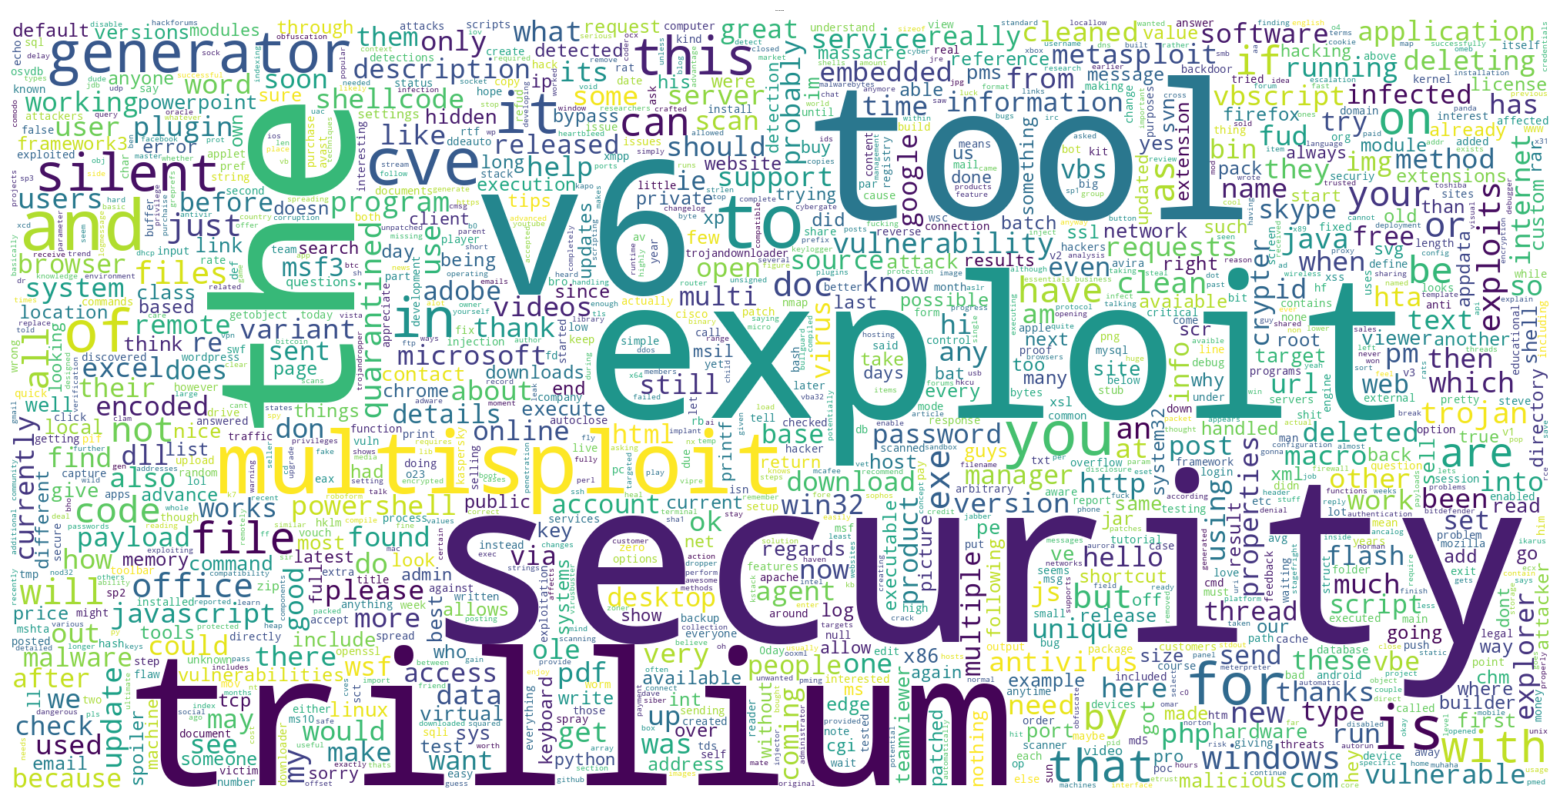

CPU times: user 33.6 s, sys: 3.93 s, total: 37.6 s
Wall time: 2min 19s


In [37]:
%%time
wc.calculate_words_frequency(documents_content, languages_list=LANGUAGE_TO_EVAL)
wc.plotWordCloud(f"All-Wordcloud", fontsize=0)